In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score, roc_curve)
try:
    from imblearn.over_sampling import SMOTE
    has_smote = True
except ImportError:
    has_smote = False

In [8]:
cols = ['age', 'sex', 'cp', 'trestbs', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

import os
data_path = "Heart_disease_cleveland_new.csv"
if not os.path.exists(data_path):
    data_path = os.path.join("..", "data", "Heart_disease_cleveland_new.csv")
if not os.path.exists(data_path):
    data_path = os.path.join("data", "Heart_disease_cleveland_new.csv")
heart_data = pd.read_csv(data_path)

print("=" *  50)
print("DATASET SUMMARY")
print("=" * 50)
print(f"Total rows        :{len(heart_data)}")
print(f"Duplicate rows    :{heart_data.duplicated().sum()}")
print(f"Missing values    :{heart_data.isnull().sum().sum()}")
print(f"\nClass Distribution   :\n{heart_data['target'].value_counts()}")
print(f"\nFirst 5 rows :\n{heart_data.head()}")

DATASET SUMMARY
Total rows        :303
Duplicate rows    :0
Missing values    :0

Class Distribution   :
target
0    164
1    139
Name: count, dtype: int64

First 5 rows :
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   0       145   233    1        2      150      0      2.3      2   
1   67    1   3       160   286    0        2      108      1      1.5      1   
2   67    1   3       120   229    0        2      129      1      2.6      1   
3   37    1   2       130   250    0        0      187      0      3.5      2   
4   41    0   1       130   204    0        2      172      0      1.4      0   

   ca  thal  target  
0   0     2       0  
1   3     1       1  
2   2     3       1  
3   0     1       0  
4   0     1       0  



EXPLORATORY DATA ANALYSIS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Statistical Summary:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mea

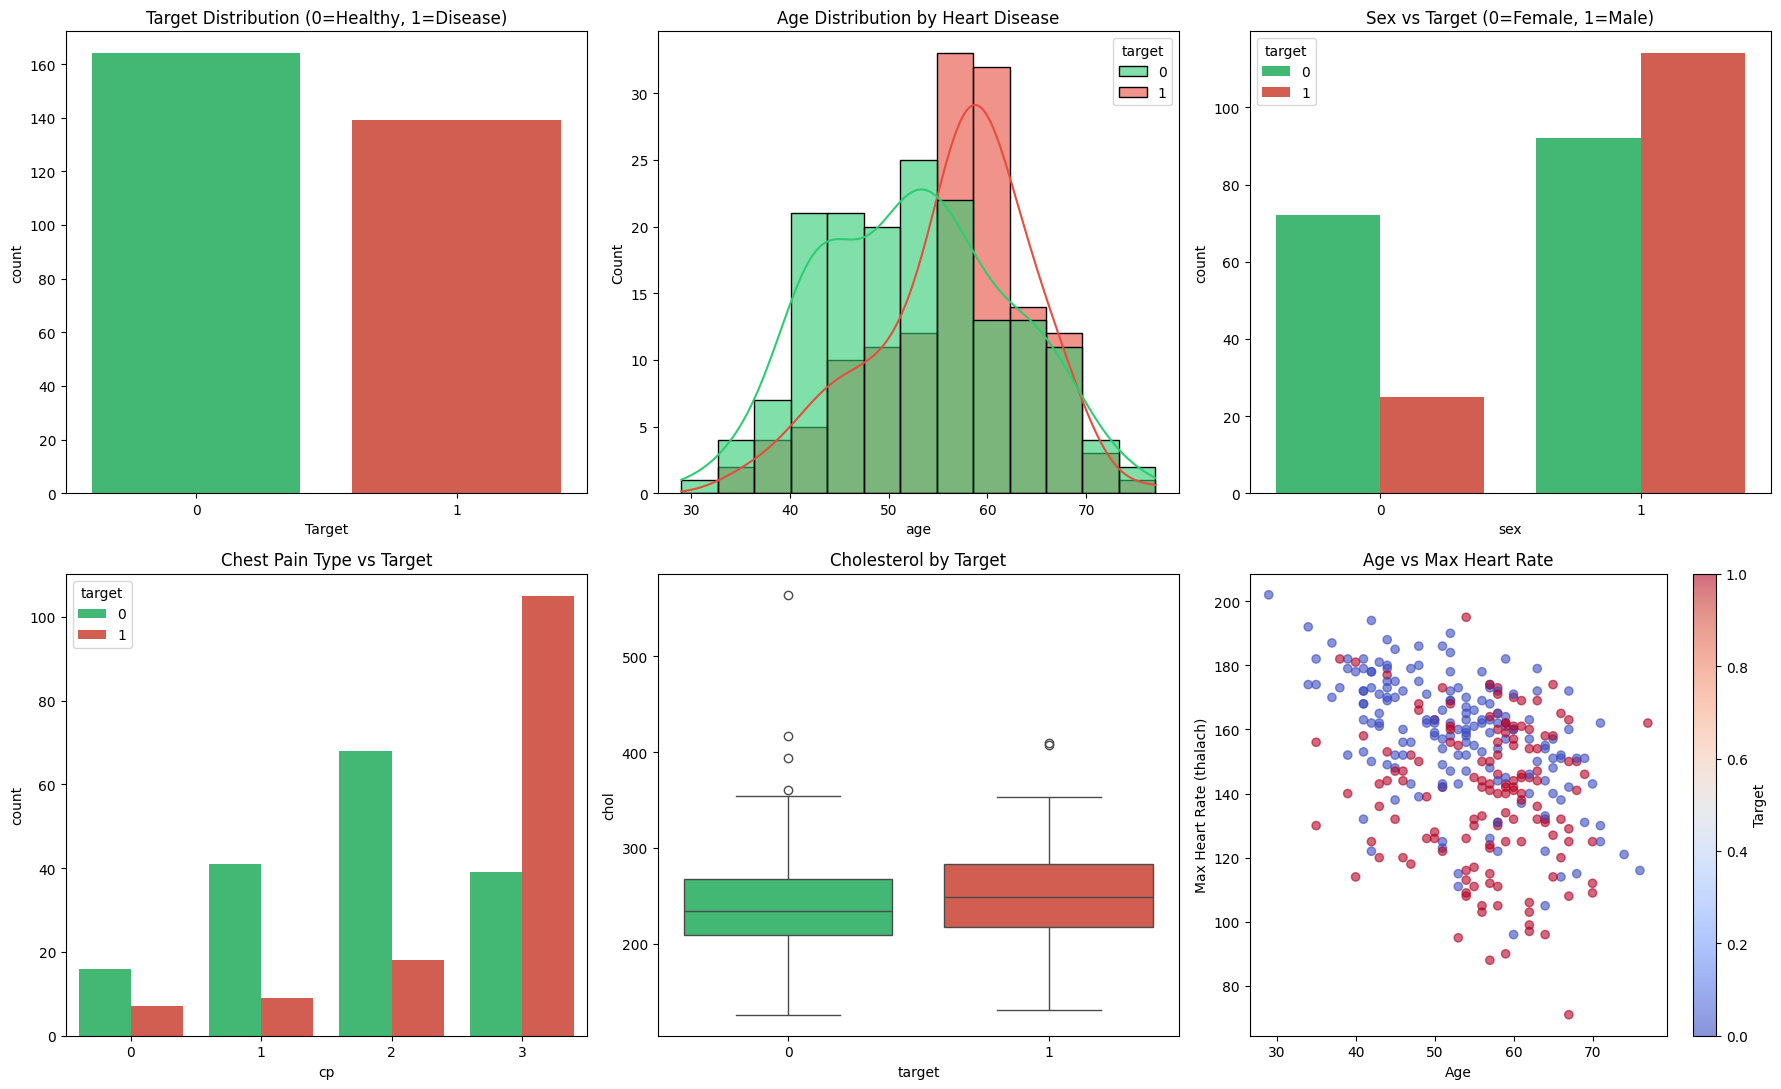

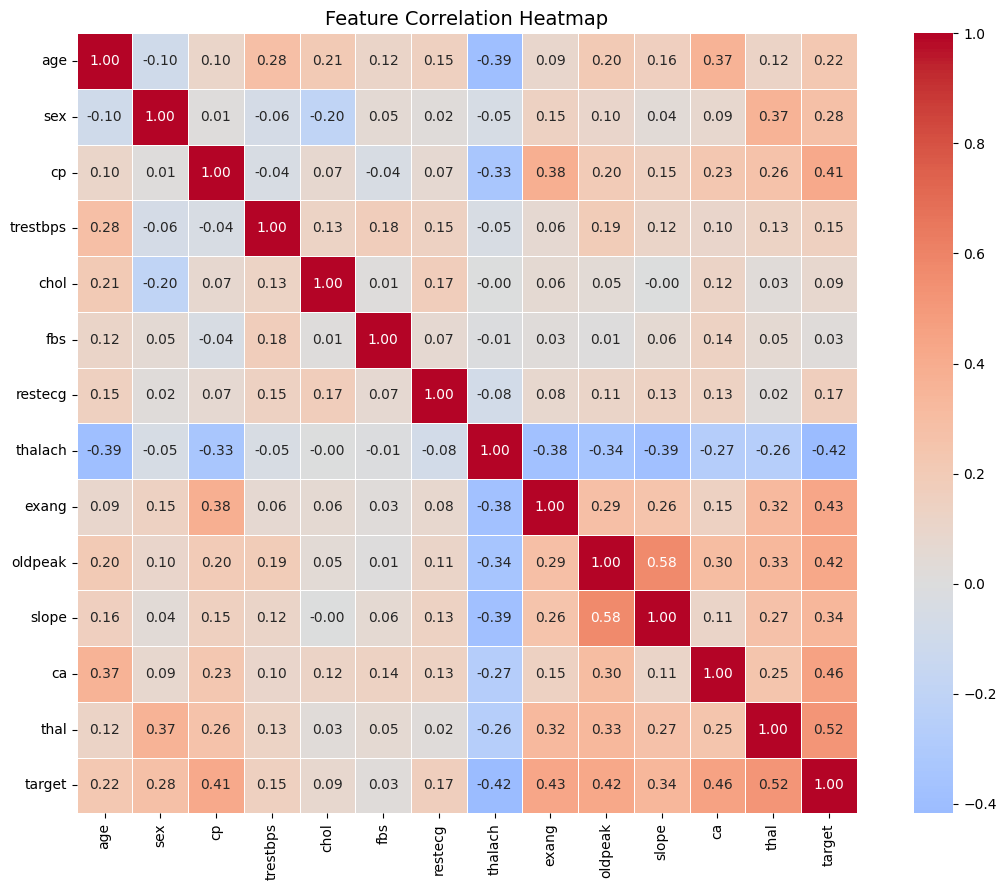

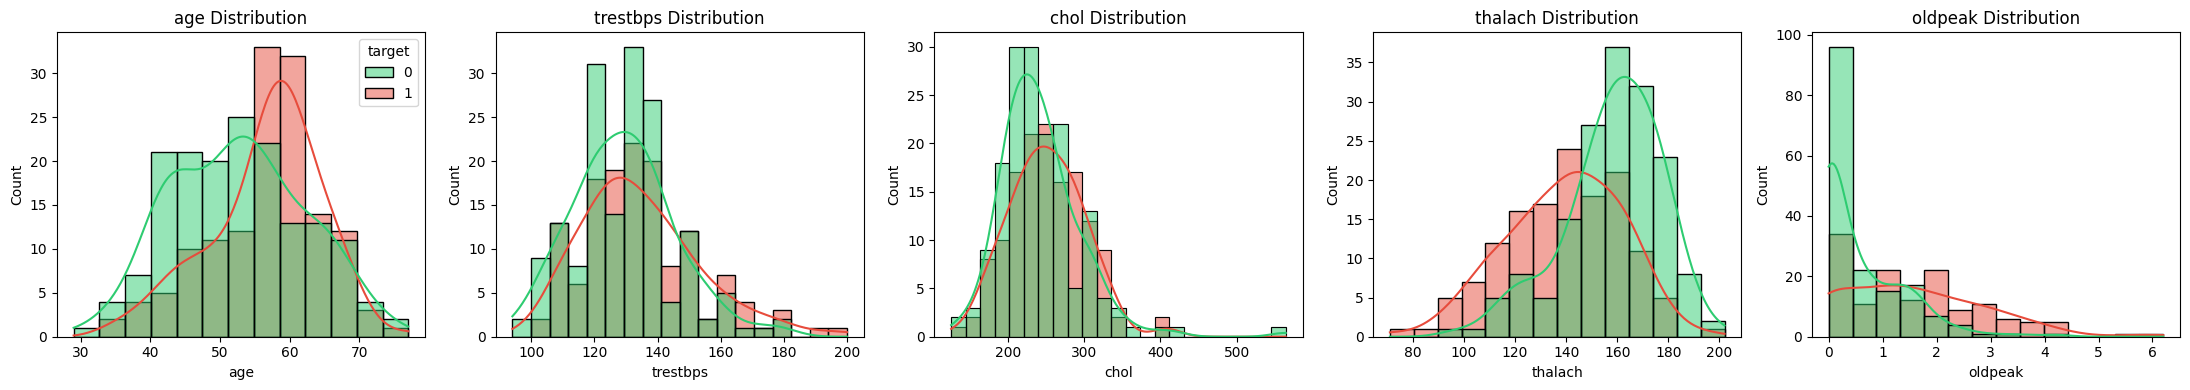


 EDA visualizations complete


In [9]:
import os
os.makedirs("plots", exist_ok=True)
print("\n" + "=" * 50)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 50)

print(heart_data.info())
print(f"\nStatistical Summary:\n{heart_data.describe()}")


fig, axes = plt.subplots(2, 3, figsize=(18, 11))

sns.countplot(data=heart_data, x='target', ax=axes[0,0], palette=['#2ecc71','#e74c3c'])
axes[0,0].set_title('Target Distribution (0=Healthy, 1=Disease)')
axes[0,0].set_xlabel('Target')

sns.histplot(data=heart_data, x='age', hue='target', kde=True, ax=axes[0,1], palette=['#2ecc71','#e74c3c'], alpha=0.6)
axes[0,1].set_title('Age Distribution by Heart Disease')

sns.countplot(data=heart_data, x='sex', hue='target', ax=axes[0,2], palette=['#2ecc71','#e74c3c'])
axes[0,2].set_title('Sex vs Target (0=Female, 1=Male)')

sns.countplot(data=heart_data, x='cp', hue='target', ax=axes[1,0], palette=['#2ecc71','#e74c3c'])
axes[1,0].set_title('Chest Pain Type vs Target')

sns.boxplot(data=heart_data, x='target', y='chol', ax=axes[1,1], palette=['#2ecc71','#e74c3c'])
axes[1,1].set_title('Cholesterol by Target')

scatter = axes[1,2].scatter(heart_data['age'], heart_data['thalach'], c=heart_data['target'], cmap='coolwarm', alpha=0.6)
axes[1,2].set_xlabel('Age')
axes[1,2].set_ylabel('Max Heart Rate (thalach)')
axes[1,2].set_title('Age vs Max Heart Rate')
plt.colorbar(scatter, ax=axes[1,2], label='Target')
plt.tight_layout()
plt.savefig("plots/eda_overview.png", dpi=150)
plt.show()

plt.figure(figsize=(12, 9))
correlation = heart_data.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=150)
plt.show()

numeric_cols = ['age','trestbps','chol','thalach','oldpeak']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for i, col in enumerate(numeric_cols):
    sns.histplot(data=heart_data, x=col, hue='target', kde=True,
                 ax=axes[i], palette=['#2ecc71','#e74c3c'], legend=(i==0))
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.savefig("plots/feature_distributions.png", dpi=150)
plt.show()

print("\n EDA visualizations complete")

In [10]:
X = heart_data.drop(columns='target')
Y = heart_data['target']

feature_cols = list(X.columns)
print(f"\nFeatures used: {feature_cols}")


Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print(f"\nTrain size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")



Train size : (242, 13)
Test size  : (61, 13)


In [12]:
print(f"\nBefore SMOTE: {dict(Y_train.value_counts())}")

if has_smote:
    smote = SMOTE(random_state=42)
    X_train_bal, Y_train_bal = smote.fit_resample(X_train, Y_train)
else:
    print("Warning: imblearn not installed. Using original training set without SMOTE.")
    X_train_bal, Y_train_bal = X_train, Y_train

print(f"After balancing/SMOTE : {dict(pd.Series(Y_train_bal).value_counts())}")


Before SMOTE: {0: np.int64(131), 1: np.int64(111)}
After SMOTE : {1: np.int64(131), 0: np.int64(131)}


In [13]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_bal, Y_train_bal)

train_acc = model.score(X_train_bal, Y_train_bal)
test_acc  = model.score(X_test, Y_test)

print("\n" + "=" * 50)
print("MODEL PERFORMANCE")
print("=" * 50)
print(f"Train Accuracy : {train_acc:.3f}")
print(f"Test Accuracy  : {test_acc:.3f}")


MODEL PERFORMANCE
Train Accuracy : 0.924
Test Accuracy  : 0.869


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, Y, cv=cv, scoring='roc_auc')

print(f"\n5-Fold CV ROC-AUC : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Per-fold scores   : {[round(s,3) for s in cv_scores]}")


5-Fold CV ROC-AUC : 0.914 ± 0.019
Per-fold scores   : [np.float64(0.95), np.float64(0.898), np.float64(0.908), np.float64(0.898), np.float64(0.914)]


In [15]:
Y_pred      = model.predict(X_test)
Y_pred_prob = model.predict_proba(X_test)[:, 1]

print(f"\nROC-AUC Score : {roc_auc_score(Y_test, Y_pred_prob):.3f}")
print("\nClassification Report:")
print(classification_report(Y_test, Y_pred, target_names=['Healthy','Diseased']))



ROC-AUC Score : 0.953

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.93      0.82      0.87        33
    Diseased       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



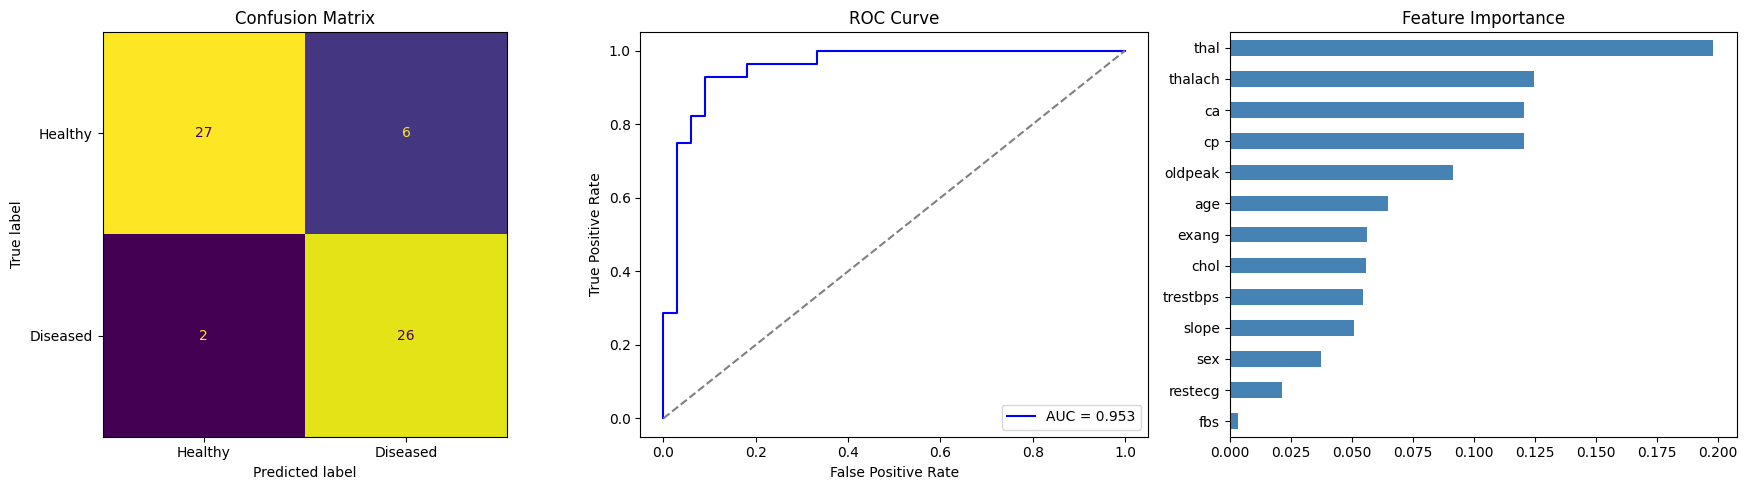

In [16]:
import os
os.makedirs("plots", exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ConfusionMatrixDisplay(
    confusion_matrix(Y_test, Y_pred),
    display_labels=['Healthy','Diseased']
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(Y_test, Y_pred_prob)
axes[1].plot(fpr, tpr, color='blue',
             label=f"AUC = {roc_auc_score(Y_test, Y_pred_prob):.3f}")
axes[1].plot([0,1],[0,1], '--', color='gray')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title("Feature Importance")

plt.tight_layout()
plt.savefig("plots/model_evaluation.png", dpi=150)
plt.show()

In [17]:
def predict_heart_disease(input_data: dict):
    input_df = pd.DataFrame([input_data], columns=feature_cols)
    prob     = model.predict_proba(input_df)[0][1] * 100

    print("\n" + "=" * 50)
    print("PREDICTION RESULT")
    print("=" * 50)
    print(f"Heart Attack Probability : {prob:.2f}%")

    if prob >= 75:
        print("Risk Level : HIGH")
        print("Advice     : Consult a cardiologist immediately.")
        print("             Monitor blood pressure & cholesterol.")
        print("             Quit smoking, adopt heart-healthy diet.")
    elif prob >= 50:
        print("Risk Level : MODERATE")
        print("Advice     : Schedule a check-up with your doctor.")
        print("             Exercise 30 mins/day, watch your diet.")
        print("             Monitor blood pressure regularly.")
    else:
        print("Risk Level : LOW")
        print("Advice     : Maintain balanced diet & active lifestyle.")
        print("             150 mins of moderate exercise weekly.")
        print("             Regular medical check-ups recommended.")

    return prob

In [18]:
sample_patient = {
    'age'     : 63,
    'sex'     : 1,
    'cp'      : 0,
    'trestbps': 145,
    'chol'    : 233,
    'fbs'     : 1,
    'restecg' : 2,
    'thalach' : 150,
    'exang'   : 0,
    'oldpeak' : 2.3,
    'slope'   : 2,
    'ca'      : 0,
    'thal'    : 2
}

predict_heart_disease(sample_patient)


PREDICTION RESULT
Heart Attack Probability : 49.10%
Risk Level : LOW
Advice     : Maintain balanced diet & active lifestyle.
             150 mins of moderate exercise weekly.
             Regular medical check-ups recommended.


np.float64(49.100076894639585)

In [19]:
with open('heart_disease_model.pkl', 'wb') as f:
    pickle.dump({
        'model'        : model,
        'features'     : feature_cols,
        'test_accuracy': round(test_acc, 3),
        'roc_auc'      : round(roc_auc_score(Y_test, Y_pred_prob), 3)
    }, f)

import os
for path in ['../models/heart_disease_model (1).pkl', 'models/heart_disease_model (1).pkl']:
    dir_name = os.path.dirname(path)
    if dir_name:
        os.makedirs(dir_name, exist_ok=True)
    try:
        with open(path, 'wb') as f:
            pickle.dump({
                'model'        : model,
                'features'     : feature_cols,
                'test_accuracy': round(test_acc, 3),
                'roc_auc'      : round(roc_auc_score(Y_test, Y_pred_prob), 3)
            }, f)
        print(f"Model also saved to: {path}")
    except Exception:
        pass

print("\nModel saved : heart_disease_model.pkl")


 Model saved → heart_disease_model.pkl


In [20]:
with open('heart_disease_model.pkl', 'rb') as f:
    saved = pickle.load(f)

loaded_model    = saved['model']
loaded_features = saved['features']

print(f"\nLoaded model accuracy : {saved['test_accuracy']}")
print(f"Loaded model ROC-AUC  : {saved['roc_auc']}")


Loaded model accuracy : 0.869
Loaded model ROC-AUC  : 0.953
